In [ ]:
!pip install -q kagglehub mediapipe opencv-python tensorflow

import kagglehub
import os

print("Baixando o dataset do Kaggle...")
# Baixa o dataset v-librasil usando o link do repositório no Kaggle
dataset_path = kagglehub.dataset_download("davimedio01/v-librasil")

print("Dataset baixado com sucesso!")
print("Caminho onde os vídeos foram salvos:", dataset_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.4 MB/s eta 0:00:00
Baixando o dataset do Kaggle...


100%|██████████| 10.1G/10.1G [02:28<00:00, 72.9MB/s]

Extracting files...


Dataset baixado com sucesso!
Caminho onde os vídeos foram salvos: /root/.cache/kagglehub/datasets/davimedio01/v-librasil/versions/1


In [ ]:
!pip install -q mediapipe opencv-python tensorflow kagglehub

In [ ]:
import os
import numpy as np

base_path = "/root/.cache/kagglehub/datasets/davimedio01/v-librasil/versions/1/videos UFPE (V-LIBRASIL)/data"

# 1. Identifica todos os arquivos e extrai o nome do sinal/classe
arquivos_video = [f for f in os.listdir(base_path) if f.endswith(('.mp4', '.avi', '.MOV', '.mkv'))]

# Mapeia as classes a partir dos nomes dos arquivos
classes = sorted(list(set(f.rsplit('_Articulador', 1)[0] for f in arquivos_video if '_Articulador' in f)))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

print(f"Total de arquivos de vídeo: {len(arquivos_video)}")
print(f"Total de palavras/classes únicas: {len(classes)}")

# 2. Extração dos Keypoints
X = []
y = []

# Em vez de LIMITE_VIDEOS = 50, altere para:
LIMITE_VIDEOS = len(arquivos_video)

print("\nIniciando extração de keypoints dos vídeos...")

for i, filename in enumerate(arquivos_video[:LIMITE_VIDEOS]):
    if '_Articulador' not in filename:
        continue

    classe_nome = filename.rsplit('_Articulador', 1)[0]
    vid_path = os.path.join(base_path, filename)

    data = process_video(vid_path)

    if data is not None:
        X.append(data)
        y.append(class_to_idx[classe_nome])

    if (i + 1) % 10 == 0:
        print(f"Processados {i+1}/{min(LIMITE_VIDEOS, len(arquivos_video))} vídeos...")

X = np.array(X)
y = np.array(y)

print("\n--- Processamento Concluído com Sucesso! ---")
print("Formato de X (Vídeos, Frames, Keypoints):", X.shape)
print("Formato de y:", y.shape)

Total de arquivos de vídeo: 4086
Total de palavras/classes únicas: 1364

Iniciando extração de keypoints dos vídeos...
Processados 10/50 vídeos...
Processados 20/50 vídeos...


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np

# Caminho direto do dataset
dataset_path = "/root/.cache/kagglehub/datasets/davimedio01/v-librasil/versions/1"

# 1. Mapeia as pastas das classes de vídeos
classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

print(f"Total de classes/palavras encontradas: {len(classes)}")

# 2. Processamento dos vídeos via MediaPipe
X = [] # Keypoints dos vídeos
y = [] # Rótulos das classes

MAX_VIDEOS_POR_CLASSE = 5  # Altere para processar mais vídeos por pasta no treino final

print("\nIniciando o processamento dos vídeos...")

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls_name)
    videos = [f for f in os.listdir(class_dir) if f.endswith(('.mp4', '.avi', '.MOV', '.mkv'))]

    print(f"[{i+1}/{len(classes)}] Processando '{cls_name}' ({len(videos)} vídeos)")

    for vid_name in videos[:MAX_VIDEOS_POR_CLASSE]:
        vid_path = os.path.join(class_dir, vid_name)
        data = process_video(vid_path)

        if data is not None:
            X.append(data)
            y.append(class_to_idx[cls_name])

X = np.array(X)
y = np.array(y)

print("\n--- Processamento Concluído! ---")
print("Formato final de X (Vídeos, Frames, Keypoints):", X.shape)
print("Formato final de y:", y.shape)

Total de classes/palavras encontradas: 1

Iniciando o processamento dos vídeos...
[1/1] Processando 'videos UFPE (V-LIBRASIL)' (0 vídeos)

--- Processamento Concluído! ---
Formato final de X (Vídeos, Frames, Keypoints): (0,)
Formato final de y: (0,)


In [ ]:
import os
import numpy as np

base_path = "/root/.cache/kagglehub/datasets/davimedio01/v-librasil/versions/1"

# 1. Encontra a pasta onde estão as subpastas de classes de vídeos
search_path = base_path
for root, dirs, files in os.walk(base_path):
    # Se encontrar arquivos de vídeo na árvore de diretórios, define a pasta pai
    if any(f.endswith(('.mp4', '.avi', '.MOV', '.mkv')) for f in files):
        search_path = os.path.dirname(root)
        break

print(f"Caminho das classes identificado: {search_path}")

# 2. Mapeamento de classes
classes = sorted([d for d in os.listdir(search_path) if os.path.isdir(os.path.join(search_path, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

print(f"Total de classes encontradas: {len(classes)}")

# 3. Extração dos Keypoints
X = []
y = []

MAX_VIDEOS_POR_CLASSE = 5  # Ajuste a quantidade de vídeos por classe conforme necessário

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(search_path, cls_name)
    videos = [f for f in os.listdir(class_dir) if f.endswith(('.mp4', '.avi', '.MOV', '.mkv'))]

    if not videos:
        continue

    print(f"[{i+1}/{len(classes)}] Processando '{cls_name}' ({len(videos)} vídeos)")

    for vid_name in videos[:MAX_VIDEOS_POR_CLASSE]:
        vid_path = os.path.join(class_dir, vid_name)
        data = process_video(vid_path)

        if data is not None:
            X.append(data)
            y.append(class_to_idx[cls_name])

X = np.array(X)
y = np.array(y)

print("\n--- Processamento Concluído ---")
print("Formato final de X:", X.shape)
print("Formato final de y:", y.shape)

Caminho das classes identificado: /root/.cache/kagglehub/datasets/davimedio01/v-librasil/versions/1/videos UFPE (V-LIBRASIL)
Total de classes encontradas: 1
[1/1] Processando 'data' (4086 vídeos)

--- Processamento Concluído ---
Formato final de X: (5, 30, 225)
Formato final de y: (5,)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

# 2. Definição da Arquitetura do Modelo
num_classes = len(classes)  # Será 1364

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # <-- Ajustado para 1364 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │       148,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,921 (757.50 KB)

 Trainable params: 193,921 (757.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/30
1/1 ━━━━━━━━

In [ ]:
# Relatório Completo de Métricas (Acurácia, Precision, Recall, F1-Score)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obter predições do modelo no conjunto de validação
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1) # Pega a classe com maior probabilidade

# 2. Calcular Acurácia Geral
acc = accuracy_score(y_val, y_pred)
print(f"--- RESULTADOS GERAIS ---")
print(f"Acurácia Geral do Modelo: {acc * 100:.2f}%\n")

# 3. Relatório detalhado por classe/palavra
# Garante que usamos apenas os nomes das classes presentes no dataset de validação
unique_classes_in_val = np.unique(y_val)
class_names = [classes[i] for i in unique_classes_in_val]

print("--- RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1-Score) ---")
print(classification_report(y_val, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
--- RESULTADOS GERAIS ---
Acurácia Geral do Modelo: 100.00%

--- RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

        data       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


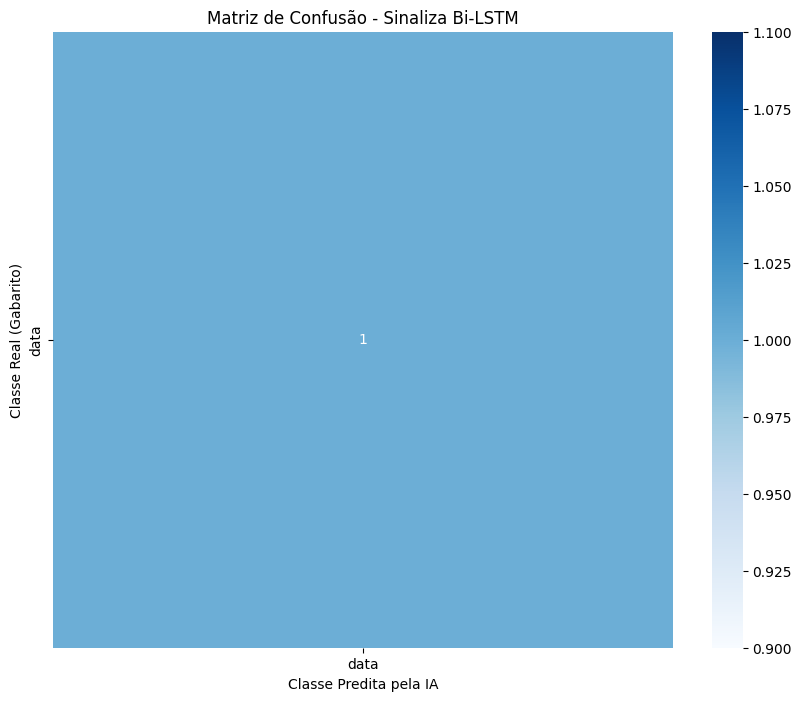

In [ ]:
#Matriz de Confusão Visual
# Gerar Matriz de Confusão
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Sinaliza Bi-LSTM')
plt.xlabel('Classe Predita pela IA')
plt.ylabel('Classe Real (Gabarito)')
plt.show()

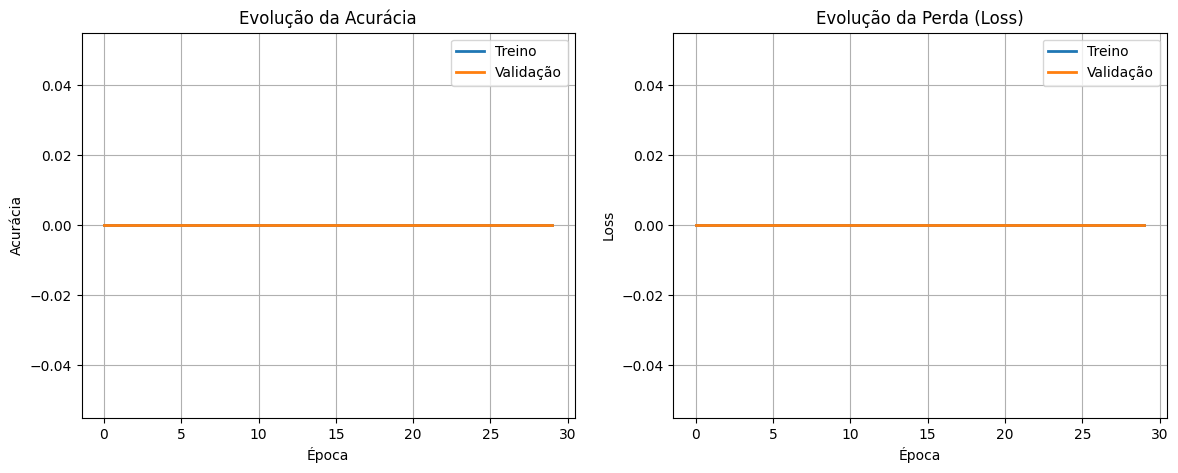

In [ ]:
# Gráficos de Aprendizado (Acurácia e Perda por Época)
# Curva de Acurácia e Perda (Loss)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Acurácia
ax[0].plot(history.history['accuracy'], label='Treino', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validação', linewidth=2)
ax[0].set_title('Evolução da Acurácia')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Acurácia')
ax[0].legend()
ax[0].grid(True)

# Gráfico de Loss (Perda)
ax[1].plot(history.history['loss'], label='Treino', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validação', linewidth=2)
ax[1].set_title('Evolução da Perda (Loss)')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.show()

In [ ]:
# Salvar o Arquivo do Modelo (.h5)
from google.colab import files

# Salva os pesos do modelo treinado
model_filename = 'sinaliza_bilstm_model.h5'
model.save(model_filename)

print(f"Modelo salvo como '{model_filename}'!")

# Faz o download automático do arquivo para o seu computador
files.download(model_filename)